### 부스팅(Boosting)

### 라이브러리 설치
- pip install xgboost
- pip install lightgbm

In [1]:
# 기본
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
sns.set()
# 그래프 기본 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False


# 데이터 전처리 알고리즘
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# 학습용과 검증용으로 나누는 함수
from sklearn.model_selection import train_test_split

# 교차 검증
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

# 평가함수
# 분류용
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

# 모델의 최적의 하이퍼 파라미터를 찾기 위한 도구
from sklearn.model_selection import GridSearchCV

# 머신러닝 알고리즘 - 분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# 혼동행렬 확인 
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# 피처중요도 확인 
import shap
import matplotlib.pyplot as plt
import pandas as pd
import xgboost as xgb

import os
import joblib

### 분류

In [3]:
# 1. 데이터 불러오기
df = pd.read_csv('./result/D_Other_VIF_col_7_with_segment.csv')

# 2. D vs Not D 데이터 구성
df_d = df.copy()

# 3. 타겟 생성: D = 0, 나머지(A/B/C/E) = 1
df_d['target'] = (df_d['Segment'] != 'D').astype(int)

# 4. 피처 / 타겟 분리
drop_cols = ['ID', 'Segment', 'target']
feature_names = df_d.drop(columns=drop_cols).columns.tolist()
X_d = df_d[feature_names].values
y_d = df_d['target'].values

# 5. train / test 분리 및 스케일링
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_d, y_d, test_size=0.2, random_state=1)

scaler_d = StandardScaler()
X_train_d = scaler_d.fit_transform(X_train_d)
X_test_d = scaler_d.transform(X_test_d)


### 기본 모델 사용하기

In [ ]:
model1 = AdaBoostClassifier()

# 교차 검증
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
r1 = cross_val_score(model1, train_X, train_y, scoring='f1', cv=kfold)
print(f'평균 f1 Score : {r1.mean()}')

In [4]:
model2 = GradientBoostingClassifier()

# 교차 검증
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
r1 = cross_val_score(model2, train_X, train_y, scoring='f1', cv=kfold)
print(f'평균 f1 Score : {r1.mean()}')

평균 f1 Score : 0.7361405570693496


In [5]:
model3 = LGBMClassifier(verbose=-1)

# 교차 검증
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
r1 = cross_val_score(model3, train_X, train_y, scoring='f1', cv=kfold)
print(f'평균 f1 Score : {r1.mean()}')

평균 f1 Score : 0.7450196078431371


In [7]:
model4 = XGBClassifier()

# 교차 검증
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
r1 = cross_val_score(model4, train_X, train_y, scoring='f1', cv=kfold)
print(f'평균 f1 Score : {r1.mean()}')

평균 f1 Score : 0.7516666800691568


### 모델 하이퍼 파라미터 튜닝

In [ ]:
# 튜닝할 하이퍼 파라미터 후보 값
# n_estimators : 트리의 개수
# learning_rate : 학습률. 오차 보정을 위해 상수 값들을 수정하는 정도

params = {
    'n_estimators' : [50, 100, 150, 200, 250, 300],
    'learning_rate' : [0.0001, 0.001, 0.01, 0.1, 1, 0, 10, 100, 1000, 10000]
}
# 사용할 모델 객체를 생성한다.
model1 = AdaBoostClassifier()
# 최적의 하이퍼 파라미터를 찾는다.
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
grid_clf = GridSearchCV(model1, param_grid=params, scoring='f1', cv=kfold)
grid_clf.fit(train_X, train_y)
print(f'최적의 하이퍼 파라미터 : {grid_clf.best_params_}')
print(f'최적의 모델 평균 성능 : {grid_clf.best_score_}')

최적의 하이퍼 파라미터 : {'learning_rate': 0.1, 'n_estimators': 150}
최적의 모델 평균 성능 : 0.7133237501232857


In [48]:
# 튜닝할 하이퍼 파라미터 후보 값
# n_estimators : 트리의 개수
# learning_rate : 학습률. 오차 보정을 위해 상수 값들을 수정하는 정도
params = {
    'n_estimators' : [50, 100, 150, 200, 250, 300],
    'learning_rate' : [0.0001, 0.001, 0.01, 0.1, 1, 0, 10, 100, 1000, 10000]
}
# 사용할 모델 객체를 생성한다.
model2 = GradientBoostingClassifier()
# 최적의 하이퍼 파라미터를 찾는다.
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
grid_clf2 = GridSearchCV(model2, param_grid=params, scoring='f1', cv=kfold)
grid_clf2.fit(train_X, train_y)
print(f'최적의 하이퍼 파라미터 : {grid_clf2.best_params_}')
print(f'최적의 모델 평균 성능 : {grid_clf2.best_score_}')

최적의 하이퍼 파라미터 : {'learning_rate': 0.1, 'n_estimators': 50}
최적의 모델 평균 성능 : 0.7568280177568103


In [49]:
# 튜닝할 하이퍼 파라미터 후보 값
# n_estimators : 트리의 개수
# learning_rate : 학습률. 오차 보정을 위해 상수 값들을 수정하는 정도
params = {
    'n_estimators' : [50, 100, 150, 200, 250, 300],
    'learning_rate' : [0.0001, 0.001, 0.01, 0.1, 1, 0, 10, 100, 1000, 10000]
}
# 사용할 모델 객체를 생성한다.
model3 = LGBMClassifier(verbose=-1)
# 최적의 하이퍼 파라미터를 찾는다.
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
grid_clf3 = GridSearchCV(model3, param_grid=params, scoring='f1', cv=kfold)
grid_clf3.fit(train_X, train_y)
print(f'최적의 하이퍼 파라미터 : {grid_clf3.best_params_}')
print(f'최적의 모델 평균 성능 : {grid_clf3.best_score_}')

최적의 하이퍼 파라미터 : {'learning_rate': 0.1, 'n_estimators': 50}
최적의 모델 평균 성능 : 0.7673411810068157


In [11]:
# 튜닝할 하이퍼 파라미터 후보 값
# booster : 내부에서 사용할 알고리즘. gbtree - 결정트리, gblinear - 선형모델
# n_estimators : 트리의 개수
# learning_rate : 학습률. 오차 보정을 위해 상수 값들을 수정하는 정도
params = {
    'booster' : ['gbtree', 'gblinear'],
    'n_estimators' : [50, 100, 150, 200, 250, 300],
    'learning_rate' : [0.0001, 0.001, 0.01, 0.1, 1, 0, 10, 100, 1000, 10000]
}
# 사용할 모델 객체를 생성한다.
model4 = XGBClassifier()
# 최적의 하이퍼 파라미터를 찾는다.
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
grid_clf4 = GridSearchCV(model4, param_grid=params, scoring='f1', cv=kfold)
grid_clf4.fit(train_X, train_y)
print(f'최적의 하이퍼 파라미터 : {grid_clf4.best_params_}')
print(f'최적의 모델 평균 성능 : {grid_clf4.best_score_}')

최적의 하이퍼 파라미터 : {'booster': 'gbtree', 'learning_rate': 0.1, 'n_estimators': 150}
최적의 모델 평균 성능 : 0.7593057778135177


### 250708 하이퍼 파라미터 튜닝

In [4]:
# 저장 경로
save_dir = "./model/D_NotD"
os.makedirs(save_dir, exist_ok=True)

# 공통 하이퍼파라미터 (빠른 테스트용)
common_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 1]
}

xgb_params = {
    **common_params,
    'booster': ['gbtree']
}

# 모델 리스트 (GPU 사용 모델만)
models = [
    ("LightGBM", LGBMClassifier(device='gpu', verbose=-1), common_params),
    ("XGBoost", XGBClassifier(
        verbosity=0,
        use_label_encoder=False,
        tree_method='gpu_hist',
        predictor='gpu_predictor'
    ), xgb_params),
]

results = []
grid_models = {}
kfold = KFold(n_splits=5, shuffle=True, random_state=1)

for name, model, param_grid in models:
    print(f"\n[{name}] GridSearchCV 시작 중...")

    grid = GridSearchCV(model, param_grid=param_grid, scoring='f1', cv=kfold, n_jobs=-1)
    grid.fit(X_train_d, y_train_d)  # D vs Not D 학습 데이터

    grid_models[name] = grid

    # 피처 정보 저장 (ID는 제외된 상태의 feature_names 사용)
    joblib.dump({
        "model": grid,
        "features": feature_names  # 기존 feature_names 사용해도 무방
    }, f"{save_dir}/{name}_gridsearch_model.pkl")

    results.append({
        "model": name,
        "best_params": grid.best_params_,
        "best_score": grid.best_score_
    })

    print(f"[{name}] 최적 파라미터: {grid.best_params_}")
    print(f"[{name}] 평균 F1 성능: {grid.best_score_:.4f}")

    result_df = pd.DataFrame(grid.cv_results_).sort_values(by='mean_test_score', ascending=False)
    result_df.to_csv(f"{save_dir}/{name}_gridsearch_results.csv", index=False)
    print(f"[{name}] 결과 CSV 저장 완료: {save_dir}/{name}_gridsearch_results.csv")

# 전체 요약 저장
results_df = pd.DataFrame(results)
results_df.to_csv(f"{save_dir}/model_tuning_results.csv", index=False)
print(f"\n전체 요약 저장 완료: {save_dir}/model_tuning_results.csv")



[LightGBM] GridSearchCV 시작 중...
[LightGBM] 최적 파라미터: {'learning_rate': 0.1, 'n_estimators': 200}
[LightGBM] 평균 F1 성능: 0.9285
[LightGBM] 결과 CSV 저장 완료: ./model/D_NotD/LightGBM_gridsearch_results.csv

[XGBoost] GridSearchCV 시작 중...
[XGBoost] 최적 파라미터: {'booster': 'gbtree', 'learning_rate': 0.1, 'n_estimators': 200}
[XGBoost] 평균 F1 성능: 0.9285
[XGBoost] 결과 CSV 저장 완료: ./model/D_NotD/XGBoost_gridsearch_results.csv

전체 요약 저장 완료: ./model/D_NotD/model_tuning_results.csv


### GradientBoosting 피처중요도 확인

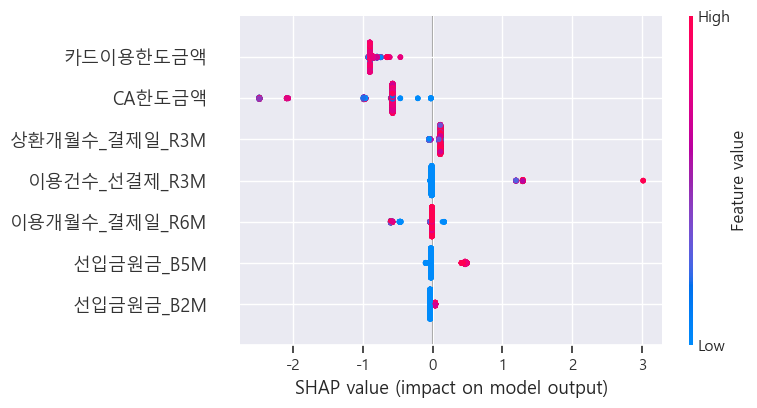

         feature  importance
0       카드이용한도금액    0.420905
1         CA한도금액    0.339192
6  이용개월수_결제일_R6M    0.075471
3      선입금원금_B2M    0.072830
2   이용건수_선결제_R3M    0.063808
5      선입금원금_B5M    0.019922
4  상환개월수_결제일_R3M    0.007872


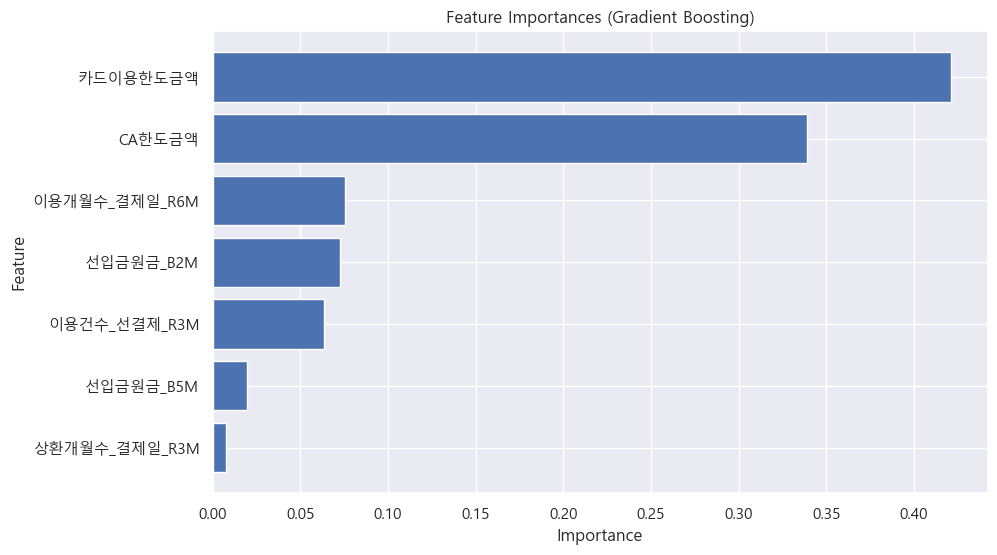

In [ ]:
# 최종 모델 지정 (GridSearchCV 사용한 경우)
final_model = grid_clf2.best_estimator_

# SHAP용 TreeExplainer 생성
explainer = shap.Explainer(final_model)  # sklearn 모델은 이렇게 생성

# 원래 데이터에서 샘플링 (해석력 보존)
X_df_original = pd.DataFrame(X, columns=df1.drop('Segment', axis=1).columns)
X_sample = X_df_original.sample(n=min(30000, len(X_df_original)), random_state=42)

# SHAP 값 계산 및 시각화
shap_values = explainer(X_sample)
shap.summary_plot(shap_values, X_sample)
plt.show()

# 중요도 추출 (GradientBoostingClassifier는 feature_importances_ 사용)
importances = final_model.feature_importances_

# 컬럼 이름 가져오기
feature_names = df1.drop('Segment', axis=1).columns.tolist()

# DataFrame 생성 및 정렬
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})
importance_df = importance_df.sort_values(by='importance', ascending=False)

# 출력
print(importance_df.head(7))

# 막대 그래프 시각화
plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importances (Gradient Boosting)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

### XG부스트 피처중요도 확인

In [82]:
# 최종 모델 지정
final_model = grid_clf4.best_estimator_

# TreeExplainer 객체 생성
explainer = shap.TreeExplainer(final_model)

# 검증 데이터에서 3만 개 샘플링 (test_X는 이미 표준화된 형태)
# → 원래 X에서 샘플링하는 게 더 해석력 높음 (스케일 전)
X_df_original = pd.DataFrame(X, columns=df1.drop('Segment', axis=1).columns)
X_sample = X_df_original.sample(n=min(30000, len(X_df_original)), random_state=42)

# 샘플 데이터에 대한 SHAP 값 계산
shap_values = explainer.shap_values(X_sample)

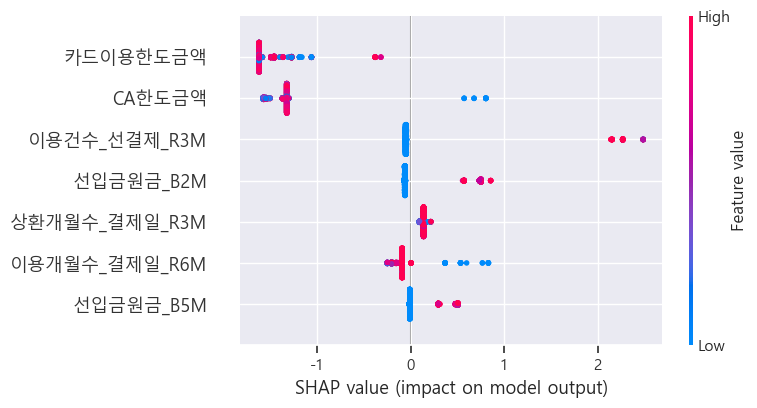

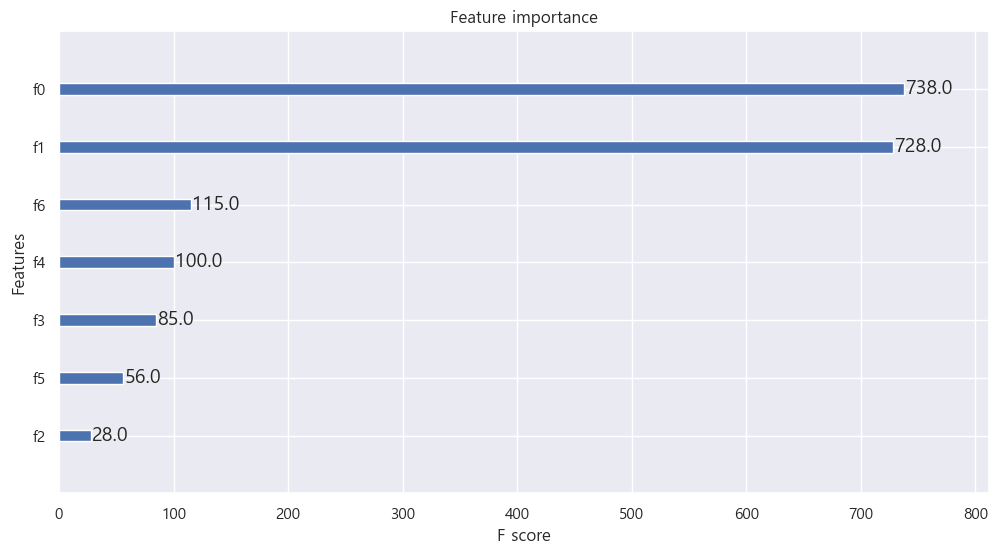

In [84]:
# SHAP 요약 플롯 그리기
shap.summary_plot(shap_values, X_sample)
plt.show()

# 중요도 시각화 (XGBoost 내장)
xgb.plot_importance(final_model)
plt.show()

In [76]:
# 3가지 지원하지만 그중 'gain'이 가장 의미 있는 기준
# gain은 예측 성능에 가장 크게 기여한 피처 파악 가능함, 해당 피처를 사용해 얻은 정보 이득의 평균

# 중요도 딕셔너리 추출
importance_dict = final_model.get_booster().get_score(importance_type='gain')

# DataFrame 먼저 생성
importance_df = pd.DataFrame(importance_dict.items(), columns=['feature', 'importance'])

# 컬럼 이름 리스트 만들기
feature_names = df1.drop('Segment', axis=1).columns.tolist()

# f0 → 실제 컬럼명으로 매핑
mapping = {f"f{i}": name for i, name in enumerate(feature_names)}
importance_df['feature'] = importance_df['feature'].map(mapping)

# 중요도 기준 정렬
importance_df = importance_df.sort_values(by='importance', ascending=False)

# 결과 출력
print(importance_df.head(7))

         feature  importance
2   이용건수_선결제_R3M    4.208557
6  이용개월수_결제일_R6M    2.270796
1         CA한도금액    1.758904
0       카드이용한도금액    1.354626
3      선입금원금_B2M    1.226646
4  상환개월수_결제일_R3M    0.805506
5      선입금원금_B5M    0.618609


### 피처중요도 확인

#####  1. SHAP 분석용 데이터 준비

In [8]:
# X: 전체 피처 데이터, df에서 Segment 컬럼 제거한 형태
feature_names = df.drop(columns=['Segment']).columns.tolist()

X_df_original = pd.DataFrame(X, columns=feature_names)
X_sample = X_df_original.sample(n=min(30000, len(X_df_original)), random_state=42)

##### 2. 시각화 함수

In [10]:
def shap_analysis(model, model_name, X_sample, feature_names, save_dir="./model/D_NotD"):
    print(f"\n[SHAP 분석 시작] {model_name}")

    try:
        if model_name == "LightGBM":
            explainer = shap.Explainer(model.booster_)
        elif model_name == "XGBoost":
            explainer = shap.TreeExplainer(model)
        else:
            raise NotImplementedError(f"{model_name} 모델에 대한 SHAP 분석은 현재 지원하지 않습니다.")

        shap_values = explainer(X_sample)

        shap.summary_plot(shap_values, X_sample, feature_names=feature_names, show=False)
        plt.title(f"SHAP Summary - {model_name}")
        plt.tight_layout()
        plt.savefig(f"{save_dir}/shap_summary_{model_name}.png")
        plt.show()

    except Exception as e:
        print(f"[SHAP 생략] {model_name}: {e}")

    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': importances
        }).sort_values(by='importance', ascending=False)

        print(f"[Feature Importance - {model_name}] 상위 7개")
        print(importance_df.head(7))

        plt.figure(figsize=(10, 6))
        plt.barh(importance_df['feature'], importance_df['importance'])
        plt.gca().invert_yaxis()
        plt.title(f"Feature Importances - {model_name}")
        plt.xlabel("Importance")
        plt.ylabel("Feature")
        plt.tight_layout()
        plt.savefig(f"{save_dir}/feature_importance_{model_name}.png")
        plt.show()


모델 로딩 중: LightGBM

[SHAP 분석 시작] LightGBM


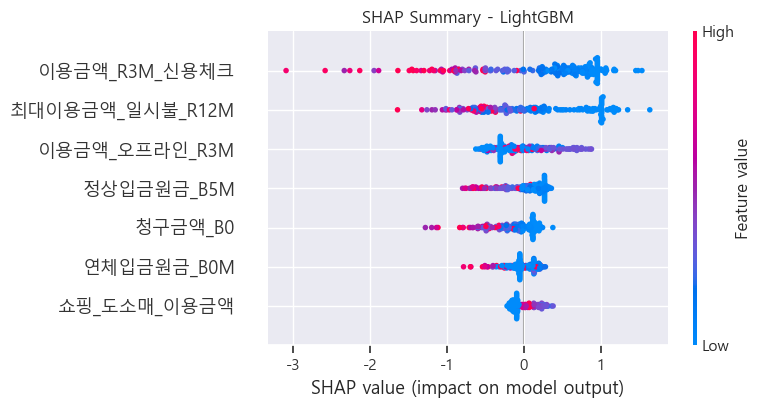

[Feature Importance - LightGBM] 상위 7개
           feature  importance
3    이용금액_오프라인_R3M        1294
0    이용금액_R3M_신용체크         933
5  최대이용금액_일시불_R12M         901
6          청구금액_B0         849
2       정상입금원금_B5M         783
1       연체입금원금_B0M         723
4      쇼핑_도소매_이용금액         517


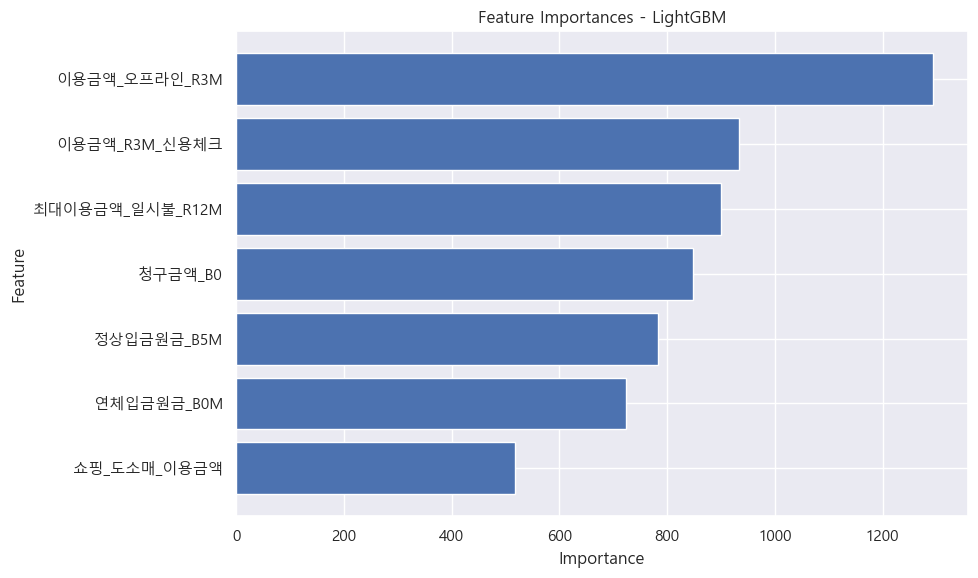


모델 로딩 중: XGBoost

[SHAP 분석 시작] XGBoost


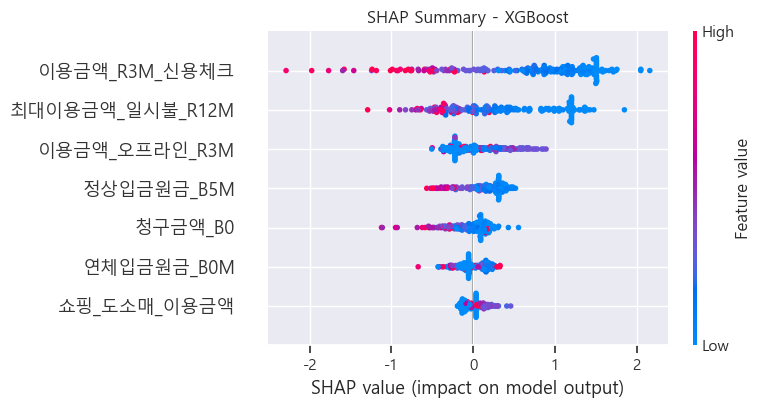

[Feature Importance - XGBoost] 상위 7개
           feature  importance
0    이용금액_R3M_신용체크    0.615485
5  최대이용금액_일시불_R12M    0.094956
6          청구금액_B0    0.084030
3    이용금액_오프라인_R3M    0.065786
2       정상입금원금_B5M    0.059267
1       연체입금원금_B0M    0.059105
4      쇼핑_도소매_이용금액    0.021370


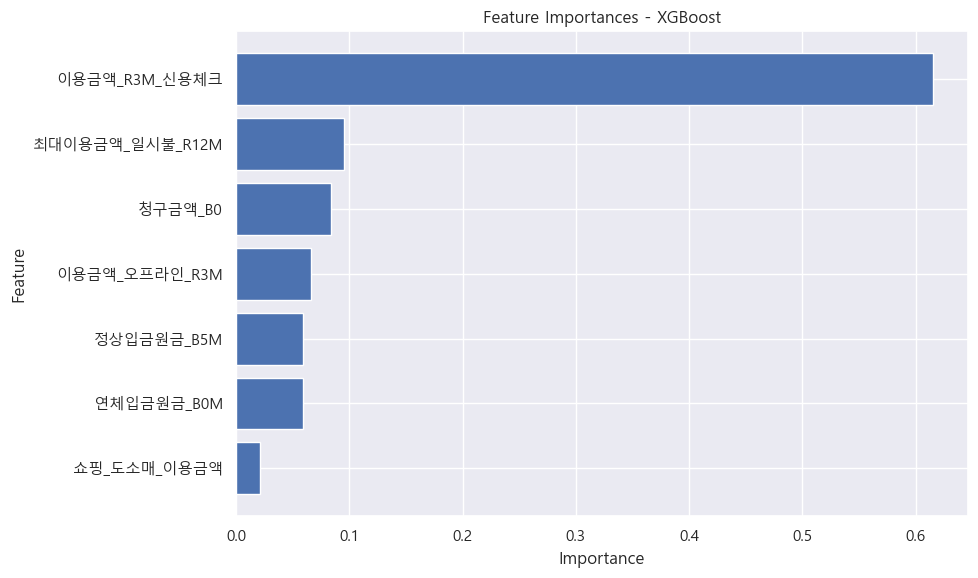

In [12]:
model_names = ["LightGBM", "XGBoost"]

# D용 샘플 준비
idx = np.random.choice(len(X_train_d), size=200, replace=False)
X_sample = X_train_d[idx]

for name in model_names:
    print(f"\n모델 로딩 중: {name}")
    model_obj = joblib.load(f"./model/D_NotD/{name}_gridsearch_model.pkl")
    model = model_obj["model"].best_estimator_
    feature_names = model_obj["features"]

    # SHAP 분석 수행 (D_NotD 경로 자동 처리됨)
    shap_analysis(model, name, X_sample, feature_names)


### PDF

In [37]:
from matplotlib.backends.backend_pdf import PdfPages
from PIL import Image
import ast

# 설정
model_names = ["AdaBoost", "GradientBoosting", "LightGBM", "XGBoost"]
base_dir = "./model/A_B"
pdf_path = f"{base_dir}/model_report.pdf"
csv_path = f"{base_dir}/model_tuning_results.csv"

# CSV에서 최적 파라미터 불러오기
params_df = pd.read_csv(csv_path).set_index("model")

# PDF 생성
with PdfPages(pdf_path) as pdf:
    for name in model_names:
        print(f"\n{name} 모델 요약 페이지 생성 중...")

        # 최적 파라미터 파싱
        best_params = params_df.loc[name, "best_params"]
        if isinstance(best_params, str):
            try:
                best_params = ast.literal_eval(best_params)
            except Exception:
                best_params = {"파라미터 파싱 실패": best_params}

        param_text = "\n".join([f"- {k}: {v}" for k, v in best_params.items()])

        # 요약 텍스트 페이지
        plt.figure(figsize=(10, 3))
        plt.axis('off')
        plt.title(f"모델: {name}", fontsize=16, loc='left')
        plt.text(0, 0.7, "최적 하이퍼파라미터", fontsize=13, fontweight='bold')
        plt.text(0, 0.4, param_text, fontsize=12)
        pdf.savefig()
        plt.close()

        # 시각화 이미지 삽입 (SHAP + feature importance)
        for plot_type in ["shap_summary", "feature_importance"]:
            img_path = f"{base_dir}/{plot_type}_{name}.png"
            if os.path.exists(img_path):
                image = Image.open(img_path)
                plt.figure(figsize=(12, 6))
                plt.imshow(image)
                plt.axis('off')
                plt.title(f"{plot_type.replace('_', ' ').title()} - {name}")
                pdf.savefig()
                plt.close()

print(f"\n모델 리포트 PDF 저장 완료: {pdf_path}")


AdaBoost 모델 요약 페이지 생성 중...

GradientBoosting 모델 요약 페이지 생성 중...

LightGBM 모델 요약 페이지 생성 중...

XGBoost 모델 요약 페이지 생성 중...

모델 리포트 PDF 저장 완료: ./model/A_B/model_report.pdf


### 학습한 데이터를 통해 검증을 한다

In [14]:
def plot_confusion_matrix(y_true, y_pred, model_name, labels=[0, 1], save_path=None):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()


[검증 평가] LightGBM 모델
Classification Report:
              precision    recall  f1-score   support

           D       0.61      0.36      0.45     69953
       Not D       0.90      0.96      0.93    410047

    accuracy                           0.87    480000
   macro avg       0.75      0.66      0.69    480000
weighted avg       0.86      0.87      0.86    480000



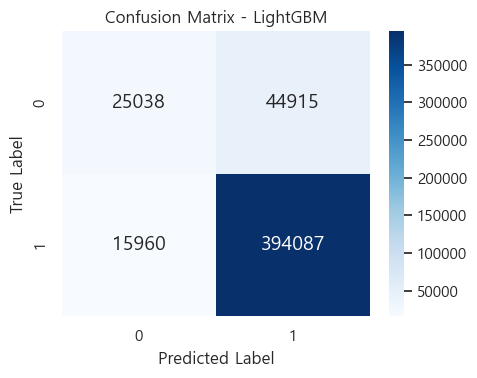


[검증 평가] XGBoost 모델
Classification Report:
              precision    recall  f1-score   support

           D       0.61      0.37      0.46     69953
       Not D       0.90      0.96      0.93    410047

    accuracy                           0.87    480000
   macro avg       0.75      0.66      0.69    480000
weighted avg       0.86      0.87      0.86    480000



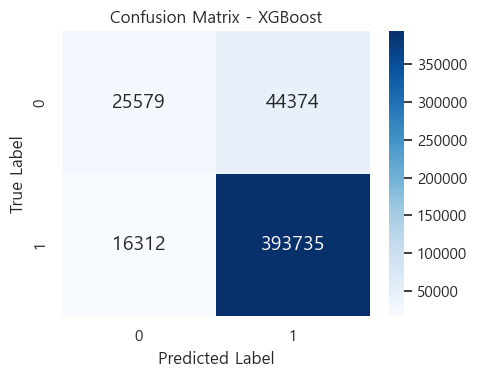

In [15]:
model_names = ["LightGBM", "XGBoost"]
model_dir = "./model/D_NotD"  # D vs Not D 모델 경로

# D용 test DataFrame 생성
test_df = pd.DataFrame(X_test_d, columns=feature_names)

for name in model_names:
    print(f"\n[검증 평가] {name} 모델")

    # 모델 및 피처 정보 로드
    obj = joblib.load(f"{model_dir}/{name}_gridsearch_model.pkl")

    if isinstance(obj, dict):
        grid = obj["model"]
        feature_names_used = obj["features"]
    else:
        grid = obj
        feature_names_used = feature_names  # fallback

    model = grid.best_estimator_

    # 테스트 데이터 컬럼 순서 맞추기
    test_X_aligned = test_df[feature_names_used]

    # 예측
    pred_y = model.predict(test_X_aligned)

    # 평가 출력
    print("Classification Report:")
    print(classification_report(y_test_d, pred_y, target_names=["D", "Not D"], zero_division=0))

    # 혼동 행렬
    plot_confusion_matrix(y_test_d, pred_y, model_name=name)


### 예측 확률 시각화


예측 확률 시각화 - LightGBM


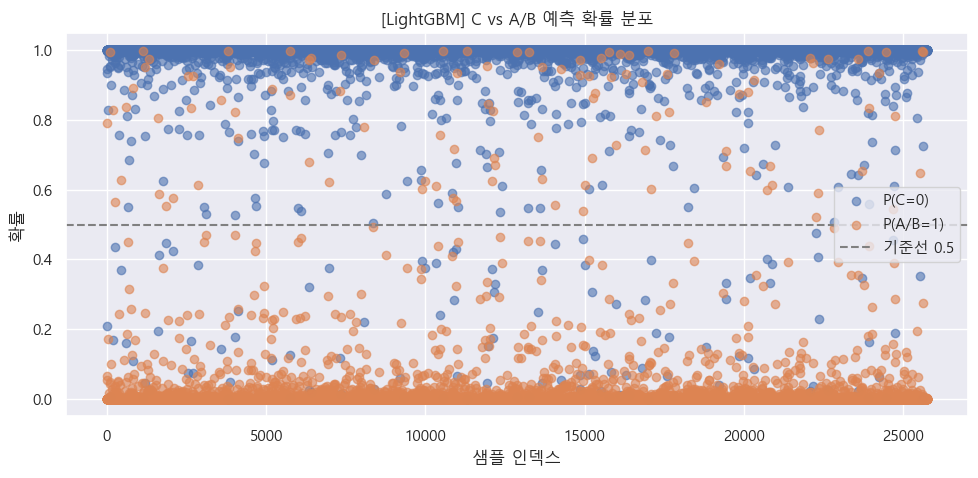


예측 확률 시각화 - XGBoost


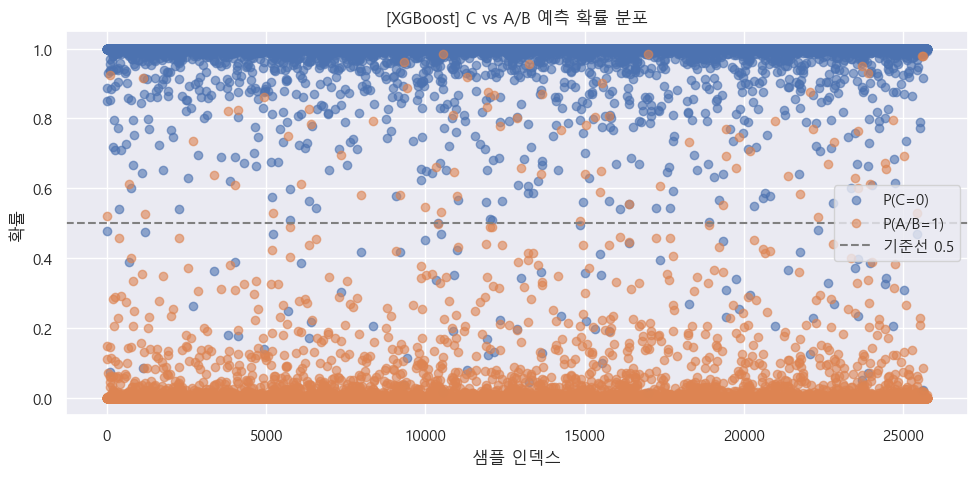

In [34]:
import joblib
import matplotlib.pyplot as plt
import os
import pandas as pd

# 모델 이름 및 디렉토리
model_names = ["LightGBM", "XGBoost"]
model_dir = "./model/C_AB"

# test_X는 표준화된 numpy 배열이고, feature_names는 피처 이름 리스트여야 함
test_df = pd.DataFrame(X_test, columns=feature_names)

for name in model_names:
    print(f"\n예측 확률 시각화 - {name}")

    model_path = f"{model_dir}/{name}_gridsearch_model.pkl"
    if not os.path.exists(model_path):
        print(f"[경고] 모델 파일 없음: {model_path}")
        continue

    # 모델 및 피처 이름 로드
    obj = joblib.load(model_path)
    grid = obj["model"]
    features_used = obj["features"]
    model = grid.best_estimator_

    # 피처 순서 맞추기
    test_X_aligned = test_df[features_used]

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(test_X_aligned)
        class0_proba = proba[:, 0]
        class1_proba = proba[:, 1]

        # 시각화
        plt.figure(figsize=(10, 5))
        plt.scatter(range(len(class0_proba)), class0_proba, label="P(C=0)", alpha=0.6)
        plt.scatter(range(len(class1_proba)), class1_proba, label="P(A/B=1)", alpha=0.6)
        plt.axhline(0.5, color='gray', linestyle='--', label='기준선 0.5')
        plt.title(f"[{name}] C vs A/B 예측 확률 분포")
        plt.xlabel("샘플 인덱스")
        plt.ylabel("확률")
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print(f"[스킵] {name} 모델은 predict_proba() 미지원")

### D 더 맞춰야 돼...

##### 가중치

In [ ]:
# 저장 경로
save_dir = "./model/D_NotD/weight"
os.makedirs(save_dir, exist_ok=True)

# 공통 하이퍼파라미터 (빠른 테스트용)
common_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 1]
}

xgb_params = {
    **common_params,
    'booster': ['gbtree']
}

# 모델 리스트 (LightGBM에 class_weight 적용)
models = [
    ("LightGBM", LGBMClassifier(device='gpu', verbose=-1, class_weight='balanced'), common_params),
    ("XGBoost", XGBClassifier(
        verbosity=0,
        use_label_encoder=False,
        tree_method='gpu_hist',
        predictor='gpu_predictor'
    ), xgb_params),
]

results = []
grid_models = {}
kfold = KFold(n_splits=5, shuffle=True, random_state=1)

for name, model, param_grid in models:
    print(f"\n[{name}] GridSearchCV 시작 중...")

    grid = GridSearchCV(model, param_grid=param_grid, scoring='f1', cv=kfold, n_jobs=-1)
    grid.fit(X_train_d, y_train_d)  # D vs Not D 학습 데이터

    grid_models[name] = grid

    # 피처 정보 저장 (ID는 제외된 상태의 feature_names 사용)
    joblib.dump({
        "model": grid,
        "features": feature_names  # 기존 feature_names 사용해도 무방
    }, f"{save_dir}/{name}_gridsearch_model.pkl")

    results.append({
        "model": name,
        "best_params": grid.best_params_,
        "best_score": grid.best_score_
    })

    print(f"[{name}] 최적 파라미터: {grid.best_params_}")
    print(f"[{name}] 평균 F1 성능: {grid.best_score_:.4f}")

    result_df = pd.DataFrame(grid.cv_results_).sort_values(by='mean_test_score', ascending=False)
    result_df.to_csv(f"{save_dir}/{name}_gridsearch_results.csv", index=False)
    print(f"[{name}] 결과 CSV 저장 완료: {save_dir}/{name}_gridsearch_results.csv")

# 전체 요약 저장
results_df = pd.DataFrame(results)
results_df.to_csv(f"{save_dir}/model_tuning_results.csv", index=False)
print(f"\n전체 요약 저장 완료: {save_dir}/model_tuning_results.csv")



[LightGBM] GridSearchCV 시작 중...
[LightGBM] 최적 파라미터: {'learning_rate': 0.1, 'n_estimators': 200}
[LightGBM] 평균 F1 성능: 0.8618
[LightGBM] 결과 CSV 저장 완료: ./model/D_NotD/weight/LightGBM_gridsearch_results.csv

[XGBoost] GridSearchCV 시작 중...
[XGBoost] 최적 파라미터: {'booster': 'gbtree', 'learning_rate': 0.1, 'n_estimators': 200}
[XGBoost] 평균 F1 성능: 0.9285
[XGBoost] 결과 CSV 저장 완료: ./model/D_NotD/weight/XGBoost_gridsearch_results.csv

전체 요약 저장 완료: ./model/D_NotD/weight/model_tuning_results.csv



[검증 평가] LightGBM 모델
Classification Report:
              precision    recall  f1-score   support

           D       0.39      0.83      0.53     69953
       Not D       0.96      0.78      0.86    410047

    accuracy                           0.79    480000
   macro avg       0.68      0.81      0.70    480000
weighted avg       0.88      0.79      0.81    480000



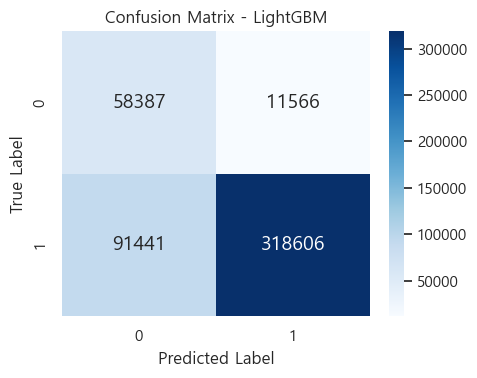


[검증 평가] XGBoost 모델
Classification Report:
              precision    recall  f1-score   support

           D       0.61      0.37      0.46     69953
       Not D       0.90      0.96      0.93    410047

    accuracy                           0.87    480000
   macro avg       0.75      0.66      0.69    480000
weighted avg       0.86      0.87      0.86    480000



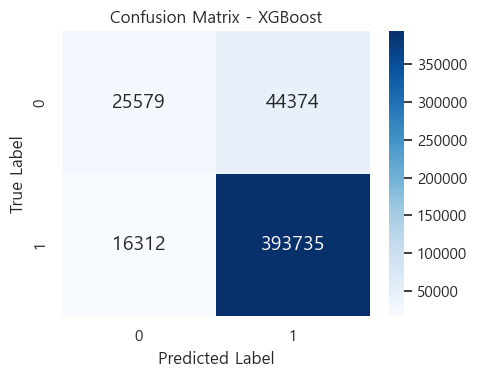

In [19]:
model_names = ["LightGBM", "XGBoost"]
model_dir = "./model/D_NotD/weight"  # D vs Not D 모델 경로

# D용 test DataFrame 생성
test_df = pd.DataFrame(X_test_d, columns=feature_names)

for name in model_names:
    print(f"\n[검증 평가] {name} 모델")

    # 모델 및 피처 정보 로드
    obj = joblib.load(f"{model_dir}/{name}_gridsearch_model.pkl")

    if isinstance(obj, dict):
        grid = obj["model"]
        feature_names_used = obj["features"]
    else:
        grid = obj
        feature_names_used = feature_names  # fallback

    model = grid.best_estimator_

    # 테스트 데이터 컬럼 순서 맞추기
    test_X_aligned = test_df[feature_names_used]

    # 예측
    pred_y = model.predict(test_X_aligned)

    # 평가 출력
    print("Classification Report:")
    print(classification_report(y_test_d, pred_y, target_names=["D", "Not D"], zero_division=0))

    # 혼동 행렬
    plot_confusion_matrix(y_test_d, pred_y, model_name=name)


### 흠...  XGBoost에 scale_pos_weight

In [24]:
from collections import Counter

# 클래스 비율 계산
class_counts = Counter(y_train_d)
n_d = class_counts[0]
n_not_d = class_counts[1]
scale_ratio = n_not_d / n_d

print(f"scale_pos_weight = {scale_ratio:.2f}")


scale_pos_weight = 5.87


In [25]:
from xgboost import XGBClassifier

xgb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'booster': ['gbtree']
}

xgb_model = XGBClassifier(
    use_label_encoder=False,
    tree_method='gpu_hist',
    predictor='gpu_predictor',
    verbosity=0,
    scale_pos_weight=scale_ratio  # 핵심: D 클래스 보정
)


In [29]:
for scale_weight in [1.0, 2.0, 3.0, 5.0]:
    print(f"\n[scale_pos_weight={scale_weight}]")
    model = XGBClassifier(
        use_label_encoder=False,
        tree_method='gpu_hist',
        predictor='gpu_predictor',
        scale_pos_weight=scale_weight,
        verbosity=0
    )
    model.fit(X_train_d, y_train_d)
    pred_y = model.predict(X_test_d)
    print(classification_report(y_test_d, pred_y, target_names=["D", "Not D"]))


[scale_pos_weight=1.0]
              precision    recall  f1-score   support

           D       0.61      0.37      0.46     69953
       Not D       0.90      0.96      0.93    410047

    accuracy                           0.87    480000
   macro avg       0.75      0.67      0.70    480000
weighted avg       0.86      0.87      0.86    480000


[scale_pos_weight=2.0]
              precision    recall  f1-score   support

           D       0.72      0.11      0.20     69953
       Not D       0.87      0.99      0.93    410047

    accuracy                           0.86    480000
   macro avg       0.79      0.55      0.56    480000
weighted avg       0.85      0.86      0.82    480000


[scale_pos_weight=3.0]
              precision    recall  f1-score   support

           D       0.78      0.04      0.07     69953
       Not D       0.86      1.00      0.92    410047

    accuracy                           0.86    480000
   macro avg       0.82      0.52      0.50    480000
we

In [27]:
import joblib
joblib.dump({
    "model": grid,
    "features": feature_names
}, "./model/D_NotD/xg_weight/xgb_scale_weight_model.pkl")


['./model/D_NotD/xg_weight/xgb_scale_weight_model.pkl']

In [28]:
from sklearn.metrics import classification_report

best_model = grid.best_estimator_
pred_y = best_model.predict(X_test_d)
print(classification_report(y_test_d, pred_y, target_names=["D", "Not D"]))

              precision    recall  f1-score   support

           D       0.83      0.00      0.00     69953
       Not D       0.85      1.00      0.92    410047

    accuracy                           0.85    480000
   macro avg       0.84      0.50      0.46    480000
weighted avg       0.85      0.85      0.79    480000



##### SMOTE + 

In [30]:
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import joblib

# 1. SMOTE 오버샘플링
sm = SMOTE(random_state=42)
X_train_d_sm, y_train_d_sm = sm.fit_resample(X_train_d, y_train_d)

print("After SMOTE:", dict(Counter(y_train_d_sm)))

# 2. XGBoost 모델 정의 (scale_pos_weight 제거)
xgb_sm_model = XGBClassifier(
    use_label_encoder=False,
    tree_method='gpu_hist',
    predictor='gpu_predictor',
    verbosity=0,
    n_estimators=200,
    learning_rate=0.1,
    booster='gbtree'
)

# 3. 학습
xgb_sm_model.fit(X_train_d_sm, y_train_d_sm)

# 4. 예측 및 평가
pred_y = xgb_sm_model.predict(X_test_d)
print("\n[SMOTE + XGBoost] Classification Report:")
print(classification_report(y_test_d, pred_y, target_names=["D", "Not D"], zero_division=0))


After SMOTE: {1: 1640711, 0: 1640711}

[SMOTE + XGBoost] Classification Report:
              precision    recall  f1-score   support

           D       0.40      0.82      0.53     69953
       Not D       0.96      0.79      0.87    410047

    accuracy                           0.79    480000
   macro avg       0.68      0.80      0.70    480000
weighted avg       0.88      0.79      0.82    480000



In [ ]:
joblib.dump({
    "model": xgb_sm_model,
    "features": feature_names
}, "./model/D_NotD/smote_xgb_model.pkl")